# Emoji Prediction from Text: Results Evaluation & Visualization
This notebook combines data preprocessing, model evaluation (Logistic Regression vs. RoBERTa), 
and custom visualization utilities for hyperparameters and training curves.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Using device: {device}")

Using device: cuda


## 1. Visualization & Helper Functions
These functions visualize model performance and training progress.

In [2]:
def show_hyperparameters():
    if os.path.exists('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/hp_tuning_results.csv'):
        hp_df = pd.read_csv('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/hp_tuning_results.csv')
        display(hp_df)
    else:
        print("HP results not found.")

show_hyperparameters()

,config_index,learning_rate,batch_size,fgm_epsilon,weight_decay,best_val_macro_f1
0,1,0.00002,16,0.3,0.01,0.330393
1,2,0.00002,32,0.5,0.01,0.325368
2,3,0.00003,32,0.5,0.00,0.315642


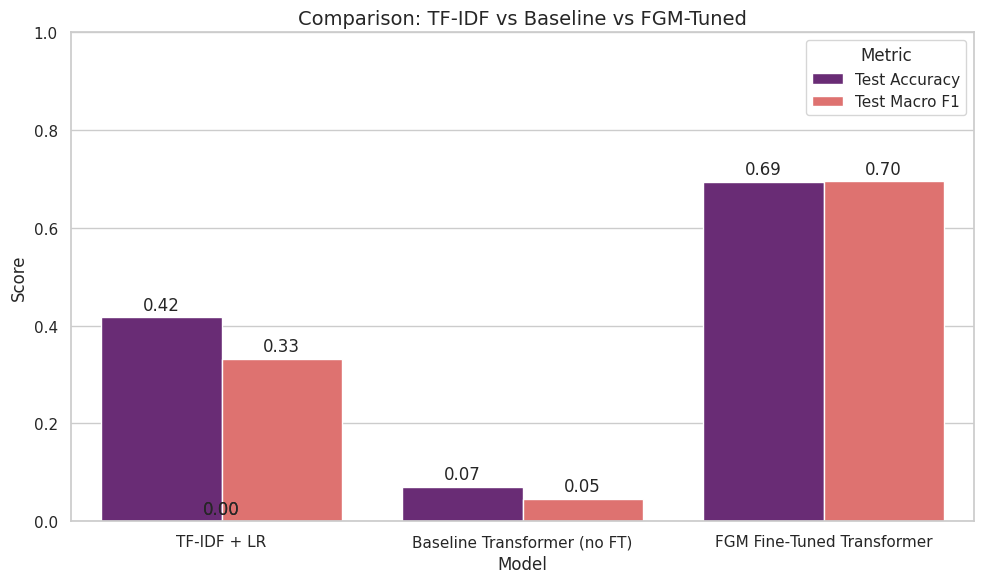

In [3]:
def plot_eval_comparison():
    if os.path.exists('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/test_results_all_models.csv'):
        results_df = pd.read_csv('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/test_results_all_models.csv')
        melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
        
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(data=melted, x='Model', y='Score', hue='Metric', palette='magma')
        plt.title('Comparison: TF-IDF vs Baseline vs FGM-Tuned', fontsize=14)
        plt.ylim(0, 1.0)
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')
        plt.tight_layout()
        plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
        plt.show()

plot_eval_comparison()

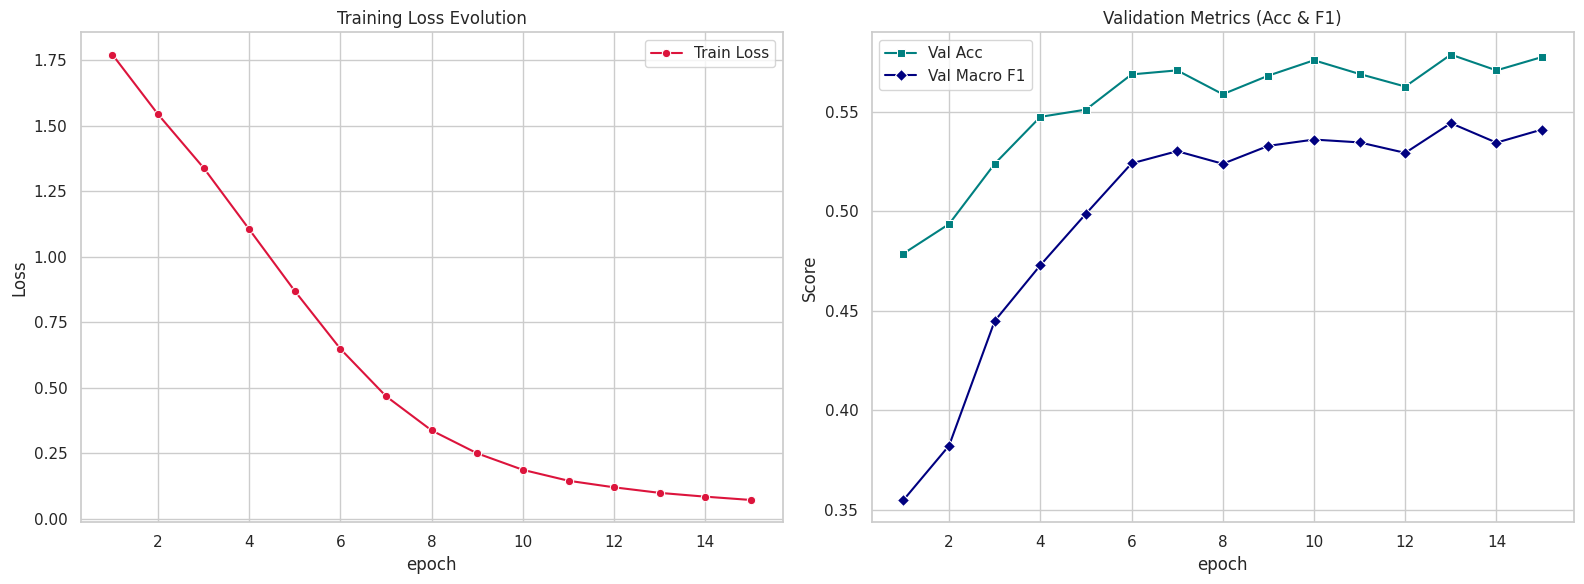

In [4]:
def plot_training_curves():
    if os.path.exists('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/final_full_training_log.csv'):
        log_df = pd.read_csv('/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/final_full_training_log.csv')
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        sns.lineplot(data=log_df, x='epoch', y='train_loss', ax=ax1, marker='o', label='Train Loss', color='crimson')
        ax1.set_title('Training Loss Evolution')
        ax1.set_ylabel('Loss')
        
        sns.lineplot(data=log_df, x='epoch', y='val_acc', ax=ax2, marker='s', label='Val Acc', color='teal')
        sns.lineplot(data=log_df, x='epoch', y='val_f1_macro', ax=ax2, marker='D', label='Val Macro F1', color='navy')
        ax2.set_title('Validation Metrics (Acc & F1)')
        ax2.set_ylabel('Score')
        
        plt.tight_layout()
        plt.savefig('/kaggle/working/learning_curves.png', dpi=150)
        plt.show()

plot_training_curves()

## 2. Load and Preprocess Data

In [5]:
train_df = pd.read_csv("/kaggle/input/datasets/nidalshahin/epft-processed-data/EPFT_train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/nidalshahin/epft-processed-data/EPFT_test.csv")

emoji_names = {
    "❤": "Heart", "😂": "Laughing", "📷": "Camera", "😎": "Cool",
    "😉": "Wink", "💯": "Hundred", "🔥": "Fire", "✨": "Sparkles",
    "😊": "Smile", "😜": "Silly", "😁": "Grin"
}
unique_labels = sorted(emoji_names.keys())
label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_name = {i: emoji_names[label] for label, i in label_to_id.items()}

train_df['label_id'] = train_df['label'].map(label_to_id)
test_df['label_id'] = test_df['label'].map(label_to_id)

## 3. PyTorch Dataset Definition

In [6]:
class EmojiDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

## 4. Model 1: TF‑IDF + Logistic Regression

In [7]:
print("\n=== Evaluating TF‑IDF + Logistic Regression ===")
tfidf_vec = TfidfVectorizer(max_features=15000, ngram_range=(1,3), stop_words='english')
X_train_tfidf = tfidf_vec.fit_transform(train_df['text'])
X_test_tfidf = tfidf_vec.transform(test_df['text'])

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, multi_class='ovr')
lr.fit(X_train_tfidf, train_df['label_id'])
y_pred_lr = lr.predict(X_test_tfidf)

target_names = [id_to_name[i] for i in sorted(id_to_name.keys())]
report_lr = classification_report(test_df['label_id'], y_pred_lr, target_names=target_names)
cm_lr = confusion_matrix(test_df['label_id'], y_pred_lr)


=== Evaluating TF‑IDF + Logistic Regression ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


## 5. Model 2: Baseline Transformer (No Fine‑Tuning)

In [8]:
print("\n=== Evaluating Baseline Transformer (no FT) ===")
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-emoji-latest")
model_base = AutoModelForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base-emoji-latest",
    num_labels=len(unique_labels),
    ignore_mismatched_sizes=True
).to(device)
model_base.eval()

test_dataset = EmojiDataset(test_df['text'].tolist(), test_df['label_id'].tolist(), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

all_preds_base, all_labels_base = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        logits = model_base(input_ids, attention_mask=attention_mask).logits
        preds = torch.argmax(logits, dim=1)
        all_preds_base.extend(preds.cpu().numpy())
        all_labels_base.extend(batch['labels'].numpy())

report_base = classification_report(all_labels_base, all_preds_base, target_names=target_names)
cm_base = confusion_matrix(all_labels_base, all_preds_base)


=== Evaluating Baseline Transformer (no FT) ===


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emoji-latest
Key                        | Status   |                                                                                        
---------------------------+----------+----------------------------------------------------------------------------------------
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([100]) vs model:torch.Size([11])          
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([100, 768]) vs model:torch.Size([11, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


## 6. Model 3: FGM Fine‑Tuned Transformer

In [9]:
print("\n=== Evaluating FGM Fine‑Tuned Transformer ===")
if os.path.exists("/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/best_fgm_model.pt"):
    state_dict = torch.load("/kaggle/input/notebooks/nidalshahin/emoji-prediction-from-text-training-pipeline/best_fgm_model.pt", map_location=device)
    model_fgm = AutoModelForSequenceClassification.from_pretrained(
        "cardiffnlp/twitter-roberta-base-emoji-latest",
        num_labels=len(unique_labels),
        ignore_mismatched_sizes=True
    )
    model_fgm.load_state_dict(state_dict)
    model_fgm = model_fgm.to(device)
    model_fgm.eval()

    all_preds_fgm, all_labels_fgm = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            logits = model_fgm(input_ids, attention_mask=attention_mask).logits
            preds = torch.argmax(logits, dim=1)
            all_preds_fgm.extend(preds.cpu().numpy())
            all_labels_fgm.extend(batch['labels'].numpy())

    report_fgm = classification_report(all_labels_fgm, all_preds_fgm, target_names=target_names)
    cm_fgm = confusion_matrix(all_labels_fgm, all_preds_fgm)
else:
    print("FGM model file not found. Skipping FGM evaluation.")
    cm_fgm = np.zeros((len(unique_labels), len(unique_labels)), dtype=int)


=== Evaluating FGM Fine‑Tuned Transformer ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-emoji-latest
Key                        | Status   |                                                                                        
---------------------------+----------+----------------------------------------------------------------------------------------
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([100]) vs model:torch.Size([11])          
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([100, 768]) vs model:torch.Size([11, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


## 7. Final Evaluation and Visualization

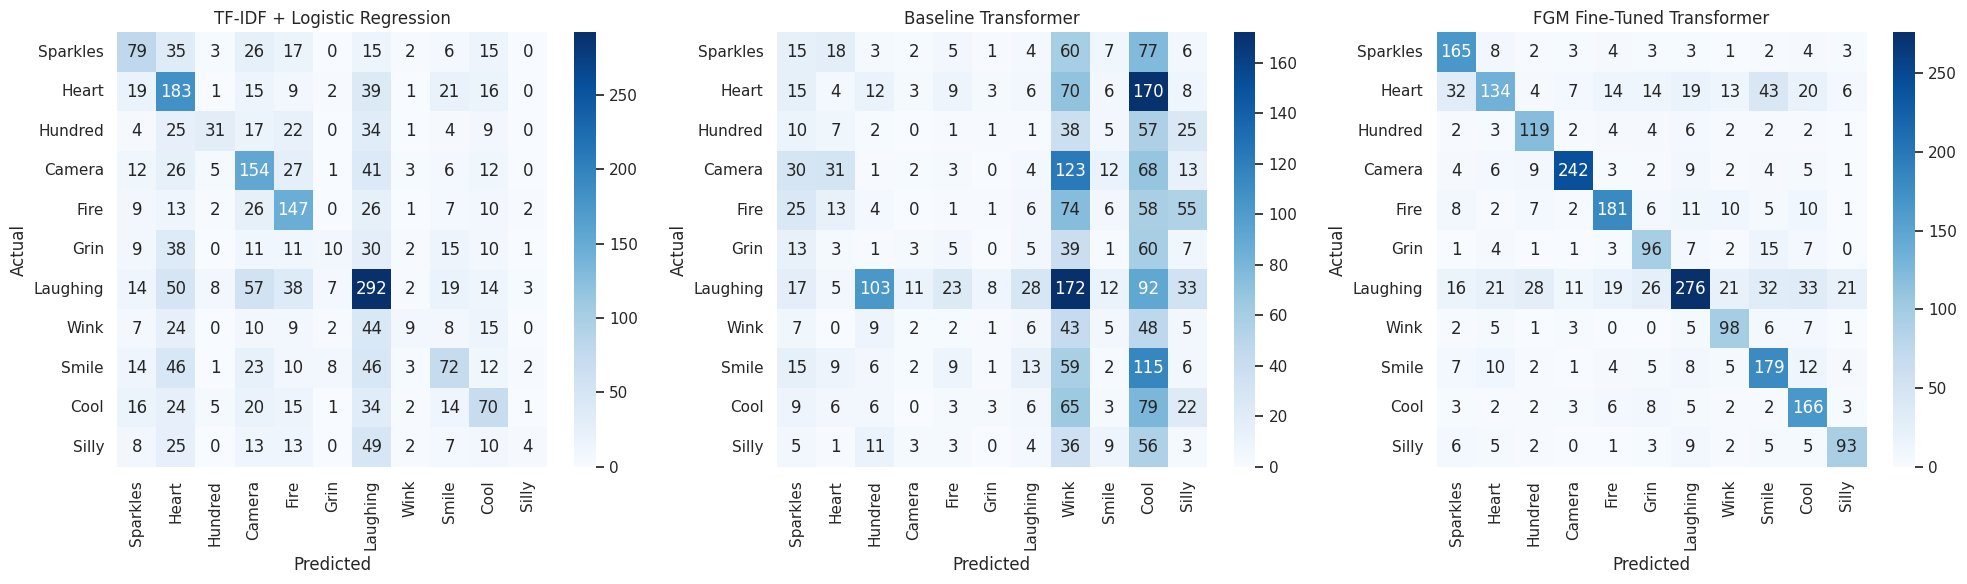

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title("TF‑IDF + Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title("Baseline Transformer")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

if 'cm_fgm' in locals() and np.sum(cm_fgm) > 0:
    sns.heatmap(cm_fgm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[2])
    axes[2].set_title("FGM Fine‑Tuned Transformer")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150)
plt.show()

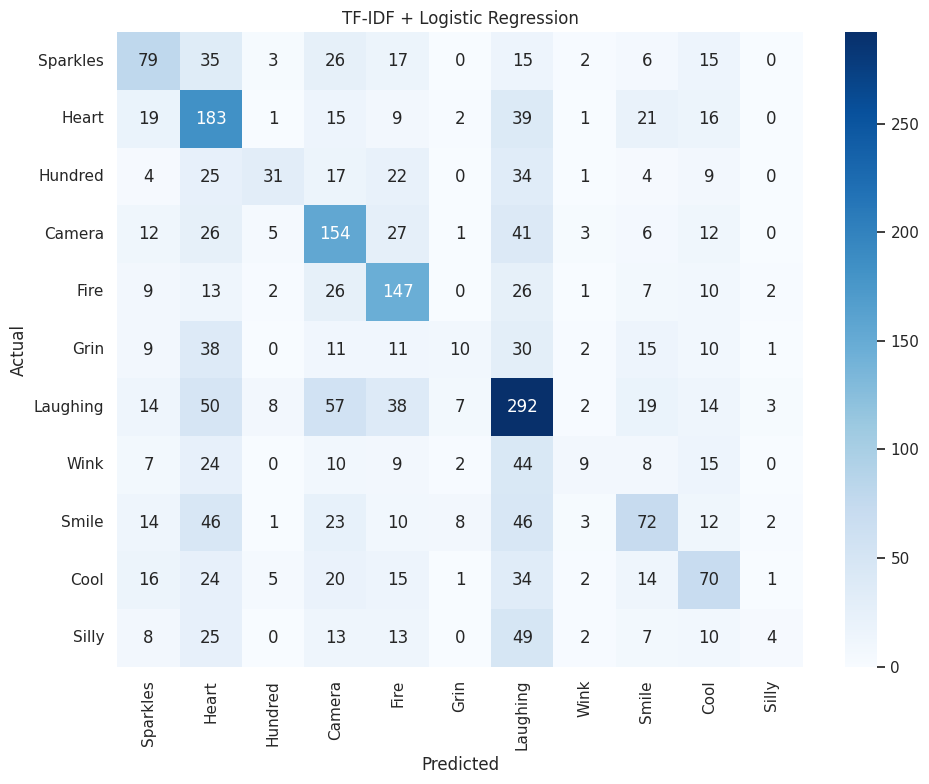

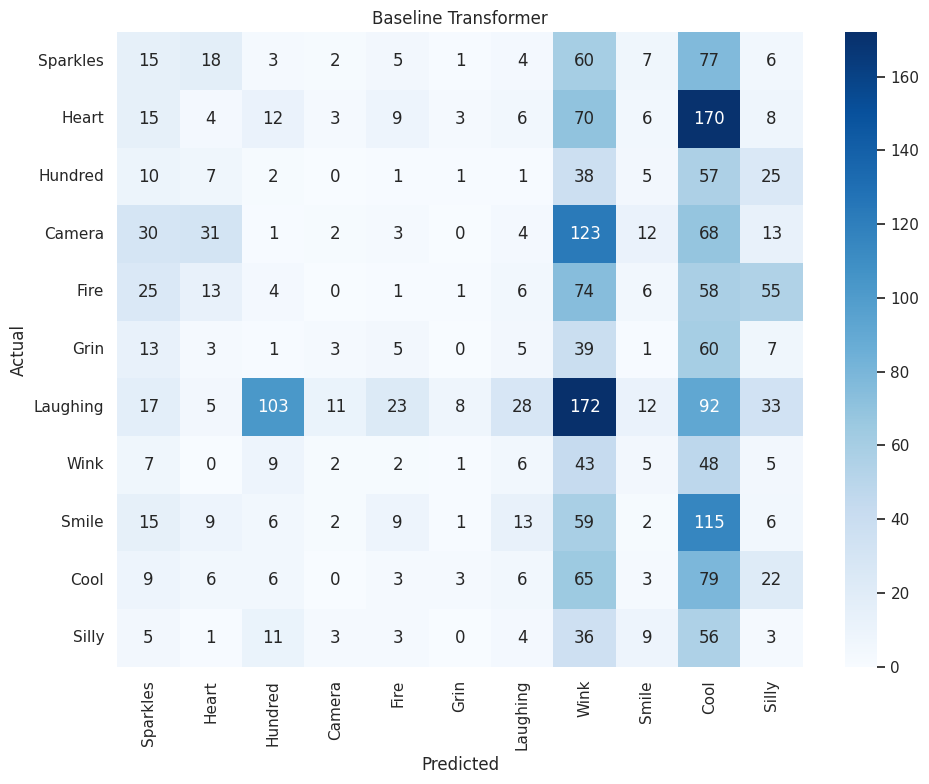

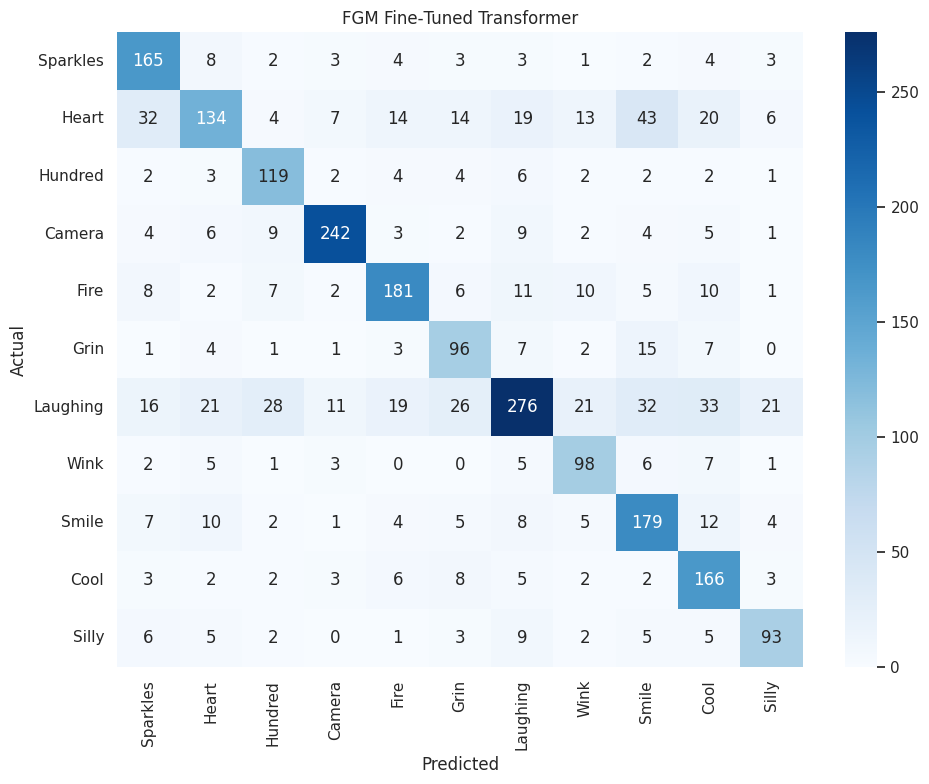

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("TF‑IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/kaggle/working/cm_lr.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Baseline Transformer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/kaggle/working/cm_base.png', dpi=150)
plt.show()

if 'cm_fgm' in locals() and np.sum(cm_fgm) > 0:
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_fgm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title("FGM Fine‑Tuned Transformer")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig('/kaggle/working/cm_fgm.png', dpi=150)
    plt.show()

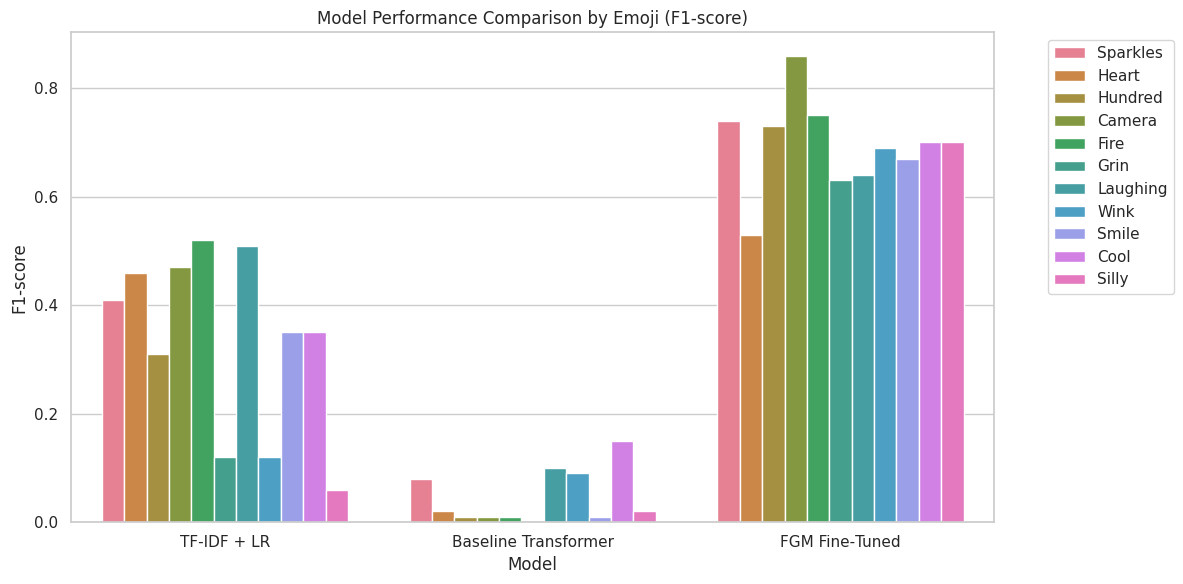

In [12]:
def plot_model_comparison(results_df):
    """Plots a bar chart comparing F1-scores across models."""
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y='F1-score', data=results_df, hue='Emoji')
    plt.title("Model Performance Comparison by Emoji (F1-score)")
    plt.xlabel("Model")
    plt.ylabel("F1-score")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    return plt.gcf()

def parse_f1_scores(report_str, model_name):
    """Extract F1-scores from classification_report string."""
    lines = report_str.split('\n')
    data = []
    for line in lines[2:-3]:
        parts = line.split()
        if len(parts) >= 5:
            emoji = parts[0]
            f1 = float(parts[3])
            data.append([model_name, emoji, f1])
    return data

all_f1_data = []
if 'report_lr' in locals():
    all_f1_data.extend(parse_f1_scores(report_lr, "TF‑IDF + LR"))
if 'report_base' in locals():
    all_f1_data.extend(parse_f1_scores(report_base, "Baseline Transformer"))
if 'report_fgm' in locals():
    all_f1_data.extend(parse_f1_scores(report_fgm, "FGM Fine‑Tuned"))

if all_f1_data:
    f1_df = pd.DataFrame(all_f1_data, columns=["Model", "Emoji", "F1-score"])
    fig = plot_model_comparison(f1_df)
    fig.savefig('/kaggle/working/f1_comparison_by_emoji.png', dpi=150)
    plt.show()
else:
    print("No classification reports found to create F1 comparison plot.")